In [8]:
from google.colab import drive
drive.mount('/content/gdrive')
import warnings
warnings.filterwarnings('ignore')
!ls /content/gdrive/MyDrive/'Colab Notebooks'/'HOPE AI'/'WEEK-8.1_Adv_ML'/'capstone'
fileloc='/content/gdrive/MyDrive/Colab Notebooks/HOPE AI/WEEK-8.1_Adv_ML/capstone/'
import seaborn as sns
import scipy.stats as stats

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Algorithm.py		    Model.ipynb		steel_melting_data.csv
Bivariate_Steel.ipynb	    Preprocessed.ipynb	Univariate.py
Deployment.ipynb	    Prep_steel.csv	Univariate_Steel.ipynb
finalized_model_random.sav  __pycache__


In [9]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/HOPE AI/WEEK-8.1_Adv_ML/capstone')
from Univariate import Univariate

In [10]:
dataset = pd.read_csv(fileloc+"Prep_steel.csv")

In [11]:
dataset.cov(numeric_only=True)

,Furnace_Temperature,Carbon_Content,Silicon_Content,Manganese_Content,Sulfur_Content,Phosphorus_Content,Oxygen_Level,Power_Consumption,Melting_Time,Cooling_Time,Scrap_Weight,Flux_Added,Steel_Strength
Furnace_Temperature,385.175770,-0.018268,6.589284e-02,0.008290,0.005741,9.103461e-03,0.706586,66.381468,3.954756,-6.689000,-6.734689,-10.822733,18.539590
Carbon_Content,-0.018268,0.007615,-2.884129e-04,0.000676,0.000040,-6.394132e-06,-0.016382,0.060064,0.016684,-0.003889,-0.036876,0.113868,0.837970
Silicon_Content,0.065893,-0.000288,7.624358e-03,0.000494,0.000023,-7.874148e-07,-0.011086,-0.111747,0.045174,-0.003955,0.012117,-0.045955,0.235317
Manganese_Content,0.008290,0.000676,4.941362e-04,0.053782,-0.000102,-8.172867e-05,0.159396,0.812605,-0.010278,0.022929,-0.004525,1.097591,0.773434
Sulfur_Content,0.005741,0.000040,2.340579e-05,-0.000102,0.000133,-1.918108e-06,0.007454,-0.019370,0.002575,-0.006361,0.000777,0.016342,-0.054504
Phosphorus_Content,0.009103,-0.000006,-7.874148e-07,-0.000082,-0.000002,7.678054e-05,0.005324,-0.000953,0.001662,-0.003695,-0.003092,0.017988,-0.023189
Oxygen_Level,0.706586,-0.016382,-1.108650e-02,0.159396,0.007454,5.324095e-03,291.428228,-38.665260,-3.548745,2.764971,1.952178,-29.693155,-37.556380
Power_Consumption,66.381468,0.060064,-1.117473e-01,0.812605,-0.019370,-9.533723e-04,-38.665260,1720.142993,-12.800829,-9.652118,9.695865,-109.455392,-38.511989
Melting_Time,3.954756,0.016684,4.517412e-02,-0.010278,0.002575,1.661943e-03,-3.548745,-12.800829,102.167419,1.411856,-6.805546,-51.848537,-44.208732
Cooling_Time,-6.689000,-0.003889,-3.955375e-03,0.022929,-0.006361,-3.694780e-03,2.764971,-9.652118,1.411856,33.514024,0.438284,2.547024,21.068320


In [12]:
Univariate.calc_vif(dataset[["Furnace_Temperature", "Power_Consumption"]])

,variables,VIF
0,Furnace_Temperature,412.296532
1,Power_Consumption,412.296532


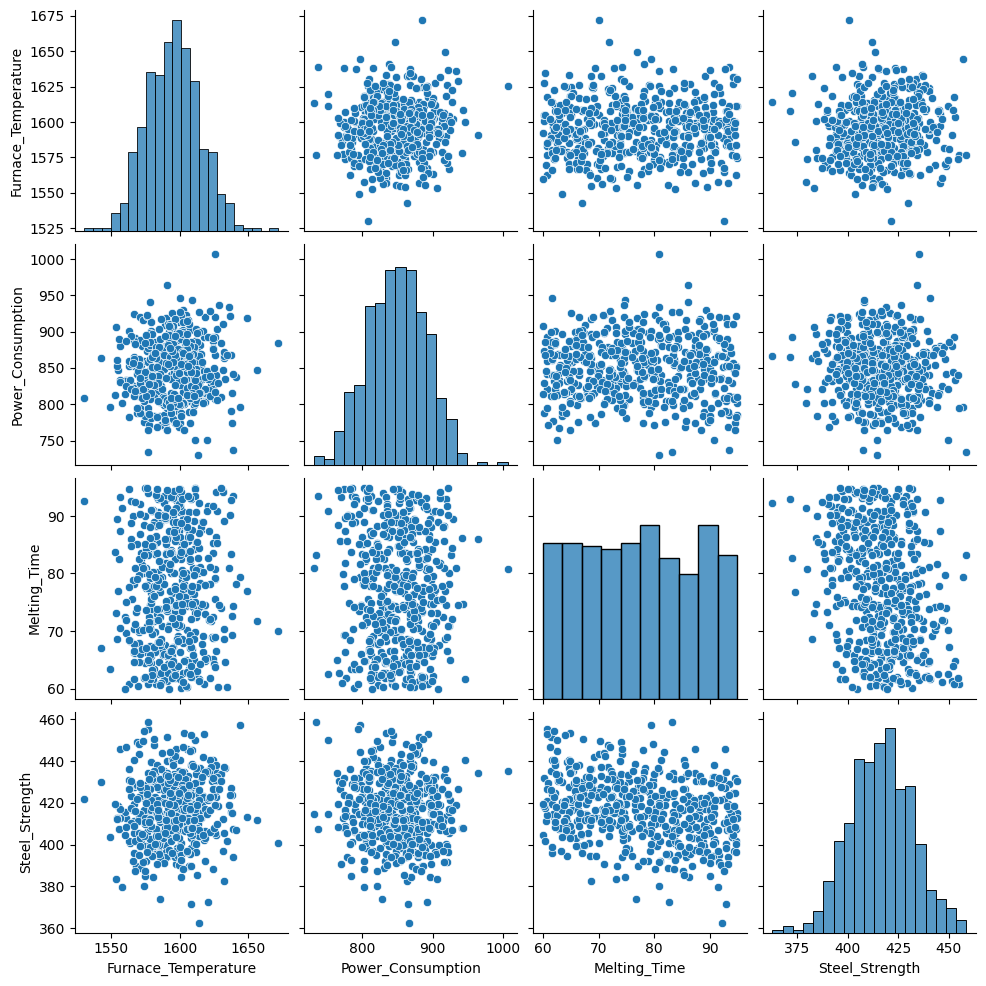

In [13]:
stats.f_oneway(dataset["Furnace_Temperature"], dataset["Steel_Strength"])

stats.f_oneway(dataset["Power_Consumption"], dataset["Steel_Strength"])

stats.f_oneway(dataset["Melting_Time"], dataset["Steel_Strength"])

dataset.corr(numeric_only=True)

sns.pairplot(
    dataset[
        [
            "Furnace_Temperature",
            "Power_Consumption",
            "Melting_Time",
            "Steel_Strength"
        ]
    ]
)